# VIA Classification – SSL ResNet-50 Backbone + EfficientNet-Style Head

This notebook contains classification experiments for VIA cervix images:

- 3-class output: **Normal / Pre-Cancerous / Cancerous**
- Backbone: **ResNet-50** pretrained with **SimCLR** on unlabeled cervix images
- Head: a lightweight **EfficientNet-style classifier**
- Two setups:
  1. **Jhpiego flashcards dataset only**
  2. **Merged dataset** combining Jhpiego flashcards + VIA_IARC images

Main steps:

1. Create tag CSVs from COCO annotations.
2. Crop flashcards to remove titles/logos.
3. Stratified train/val/test splits.
4. Class-weighted training to handle imbalance.
5. Train the SSL ResNet-50 + Efficient head (Stage 1: head-only, Stage 2: full fine-tune).
6. Evaluate with confusion matrices and curves.
7. Simple Gradio GUI for testing the classifier interactively.


In [2]:
# Setup & Imports
!pip install -q torch torchvision pandas scikit-learn matplotlib seaborn gradio

import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

import pandas as pd
import numpy as np
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## 2. Mount Google Drive and Define Paths

All data (flashcards, VIA_IARC, SSL backbone, and outputs) are stored in my Google Drive.
Here I mount Drive and define the key root folders:

- `FLASHCARDS_ROOT`: Jhpiego flashcards Roboflow export
- `CROPPED_ROOT`: cropped flashcards (no logo/text)
- `IARC_ROOT`: VIA_IARC dataset from Roboflow
- `SSL_BACKBONE_PATH`: SimCLR-pretrained ResNet-50 checkpoint
- `RESULTS_DIR`: where I save best/last models and figures


In [3]:
#Mounts and paths
from google.colab import drive
drive.mount('/content/drive')

# --- Adjust these if needed ---
FLASHCARDS_ROOT = Path("/content/drive/MyDrive/FLASHCARDS_DATA")
CROPPED_ROOT    = FLASHCARDS_ROOT / "CROPPED_FLASHCARDS"

IARC_ROOT       = Path("/content/drive/MyDrive/VIA_IARC.v1i.coco")

SSL_BACKBONE_PATH = FLASHCARDS_ROOT / "ssl_backbone_resnet50_epoch48.pth"

RESULTS_DIR = Path("/content/drive/MyDrive/classification_expts")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("FLASHCARDS_ROOT:", FLASHCARDS_ROOT)
print("CROPPED_ROOT:", CROPPED_ROOT)
print("IARC_ROOT:", IARC_ROOT)
print("SSL_BACKBONE_PATH:", SSL_BACKBONE_PATH)
print("RESULTS_DIR:", RESULTS_DIR)


Mounted at /content/drive
FLASHCARDS_ROOT: /content/drive/MyDrive/FLASHCARDS_DATA
CROPPED_ROOT: /content/drive/MyDrive/FLASHCARDS_DATA/CROPPED_FLASHCARDS
IARC_ROOT: /content/drive/MyDrive/VIA_IARC.v1i.coco
SSL_BACKBONE_PATH: /content/drive/MyDrive/FLASHCARDS_DATA/ssl_backbone_resnet50_epoch48.pth
RESULTS_DIR: /content/drive/MyDrive/classification_expts


## 3. Creating Tag Files from COCO Annotations (FLASHCARDS)

The Jhpiego flashcards are annotated in COCO format by Roboflow.

Here I convert the `*_annotations.coco.json` files into simple tag CSVs with:

- `image`
- `Cancer status` (0 = Normal, 1 = Pre-cancerous, 2 = Cancerous)
- `Candidacy` (optional: 0 = Bad-candidate, 1 = Good-candidate)

This step is run for `train`, `valid`, and `test` splits.
If the CSVs already exist, you can skip this cell.


In [4]:
# Creating tag files from COCO annotations
import json
import csv

json_paths = [
    FLASHCARDS_ROOT / "train" / "_annotations.coco.json",
    FLASHCARDS_ROOT / "valid" / "_annotations.coco.json",
    FLASHCARDS_ROOT / "test"  / "_annotations.coco.json",
]

cancer_map = {
    "Normal": 0,
    "Pre-cancerous": 1,
    "Cancerous": 2,
}

candidacy_map = {
    "Bad-candidate": 0,
    "Good-candidate": 1,
}

for json_path in json_paths:
    if not json_path.exists():
        print(f"JSON file missing: {json_path}")
        continue

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    rows = []
    for img in data.get("images", []):
        file_name = img["file_name"]
        tags = img.get("extra", {}).get("user_tags", [])

        cancer_status = None
        candidacy = None

        for tag in tags:
            if tag in cancer_map:
                cancer_status = cancer_map[tag]
            if tag in candidacy_map:
                candidacy = candidacy_map[tag]

        # if no cancer-status tag, skip this image
        if cancer_status is None:
            continue

        if candidacy is None:
            candidacy = ""

        rows.append([file_name, cancer_status, candidacy])

    csv_name = "_tags.csv"
    csv_path = json_path.parent / csv_name

    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["image", "Cancer status", "Candidacy"])
        writer.writerows(rows)

    print(f"✓ CSV created: {csv_path} (rows = {len(rows)})")


✓ CSV created: /content/drive/MyDrive/FLASHCARDS_DATA/train/_tags.csv (rows = 80)
✓ CSV created: /content/drive/MyDrive/FLASHCARDS_DATA/valid/_tags.csv (rows = 17)
✓ CSV created: /content/drive/MyDrive/FLASHCARDS_DATA/test/_tags.csv (rows = 17)


## 4. Cropping Flashcards to Remove Titles and Logos

The raw flashcards have borders, titles, and the Jhpiego logo at the bottom.  
To prevent the model from learning these artifacts, I crop each image around the cervix region using a dark-region heuristic:

1. Ignore the top 15% (title) and bottom region (logo area).
2. Detect dark pixels corresponding to the cervix photo.
3. Crop tightly around that region.
4. Save to `CROPPED_FLASHCARDS/train_images`, `val_images`, `test_images`.
5. Write new CSVs:
   - `train_tags.csv`, `val_tags.csv`, `test_tags.csv`
   - Each row has updated `image` and an `image_path` column.



In [5]:
import numpy as np
from PIL import Image

train_img_dir_src = FLASHCARDS_ROOT / "train"
val_img_dir_src   = FLASHCARDS_ROOT / "valid"
test_img_dir_src  = FLASHCARDS_ROOT / "test"

train_csv_src = train_img_dir_src / "_tags.csv"
val_csv_src   = val_img_dir_src   / "_tags.csv"
test_csv_src  = test_img_dir_src  / "_tags.csv"

train_out_img = CROPPED_ROOT / "train_images"
val_out_img   = CROPPED_ROOT / "val_images"
test_out_img  = CROPPED_ROOT / "test_images"

train_out_csv = CROPPED_ROOT / "train_tags.csv"
val_out_csv   = CROPPED_ROOT / "val_tags.csv"
test_out_csv  = CROPPED_ROOT / "test_tags.csv"


def detect_cervix_region(img, dark_thresh=235, margin=8):
    gray = img.convert("L")
    arr = np.array(gray)
    H, W = arr.shape

    # focus on center vertical band
    y0 = int(0.15 * H)  # ignore title
    y1 = int(0.60 * H)  # stop before logo

    roi = arr[y0:y1, :]

    mask = roi < dark_thresh
    if mask.sum() < 50:
        # fallback fixed box
        top    = int(0.18 * H)
        bottom = int(0.55 * H)
        left   = int(0.20 * W)
        right  = int(0.80 * W)
        return left, top, right, bottom

    ys, xs = np.where(mask)

    top    = max(0, y0 + ys.min() - margin)
    bottom = min(H, y0 + ys.max() + margin)
    left   = max(0, xs.min() - margin)
    right  = min(W, xs.max() + margin)

    max_bottom = int(0.62 * H)
    bottom = min(bottom, max_bottom)

    if right <= left:
        right = min(W, left + 10)
    if bottom <= top:
        bottom = min(H, top + 10)

    return left, top, right, bottom


def crop_cervix_image(src_path: str, dst_path: str):
    img = Image.open(src_path).convert("RGB")
    left, top, right, bottom = detect_cervix_region(img)
    crop = img.crop((left, top, right, bottom))
    Path(dst_path).parent.mkdir(parents=True, exist_ok=True)
    crop.save(dst_path)


def rewrite_csv_to_cropped(csv_in: Path, img_root: Path,
                           out_img_root: Path, csv_out: Path):
    img_root = Path(img_root)
    out_img_root = Path(out_img_root)
    out_img_root.mkdir(parents=True, exist_ok=True)

    rows_out = []

    with open(csv_in, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        if "image" not in (reader.fieldnames or []):
            raise ValueError(f"{csv_in} must have an 'image' column")

        for r in reader:
            r = dict(r)
            fname = r["image"].strip()
            src_path = img_root / fname

            if not src_path.exists():
                print(f"WARNING: image not found: {src_path}")
                continue

            stem = Path(fname).stem
            ext = Path(fname).suffix or ".jpg"
            new_name = stem + "_crop" + ext
            dst_path = out_img_root / new_name

            crop_cervix_image(str(src_path), str(dst_path))

            r["image"] = new_name
            r["image_path"] = str(dst_path)
            rows_out.append(r)

    if not rows_out:
        raise RuntimeError(f"No rows written for {csv_out}")

    headers_out = list(rows_out[0].keys())
    with open(csv_out, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=headers_out)
        w.writeheader()
        w.writerows(rows_out)

    print(f"✔ Wrote cropped CSV: {csv_out}")
    print(f"  Cropped images dir: {out_img_root}")


rewrite_csv_to_cropped(train_csv_src, train_img_dir_src, train_out_img, train_out_csv)
rewrite_csv_to_cropped(val_csv_src,   val_img_dir_src,   val_out_img,   val_out_csv)
rewrite_csv_to_cropped(test_csv_src,  test_img_dir_src,  test_out_img,  test_out_csv)

print("\n✅ Cropping done. Use CROPPED_FLASHCARDS/* for training.")


✔ Wrote cropped CSV: /content/drive/MyDrive/FLASHCARDS_DATA/CROPPED_FLASHCARDS/train_tags.csv
  Cropped images dir: /content/drive/MyDrive/FLASHCARDS_DATA/CROPPED_FLASHCARDS/train_images
✔ Wrote cropped CSV: /content/drive/MyDrive/FLASHCARDS_DATA/CROPPED_FLASHCARDS/val_tags.csv
  Cropped images dir: /content/drive/MyDrive/FLASHCARDS_DATA/CROPPED_FLASHCARDS/val_images
✔ Wrote cropped CSV: /content/drive/MyDrive/FLASHCARDS_DATA/CROPPED_FLASHCARDS/test_tags.csv
  Cropped images dir: /content/drive/MyDrive/FLASHCARDS_DATA/CROPPED_FLASHCARDS/test_images

✅ Cropping done. Use CROPPED_FLASHCARDS/* for training.


## 5. Visual Check of Cropped Flashcards

Here I randomly sample a few images from the cropped train/val/test sets
to confirm that the logos and titles have been removed properly.


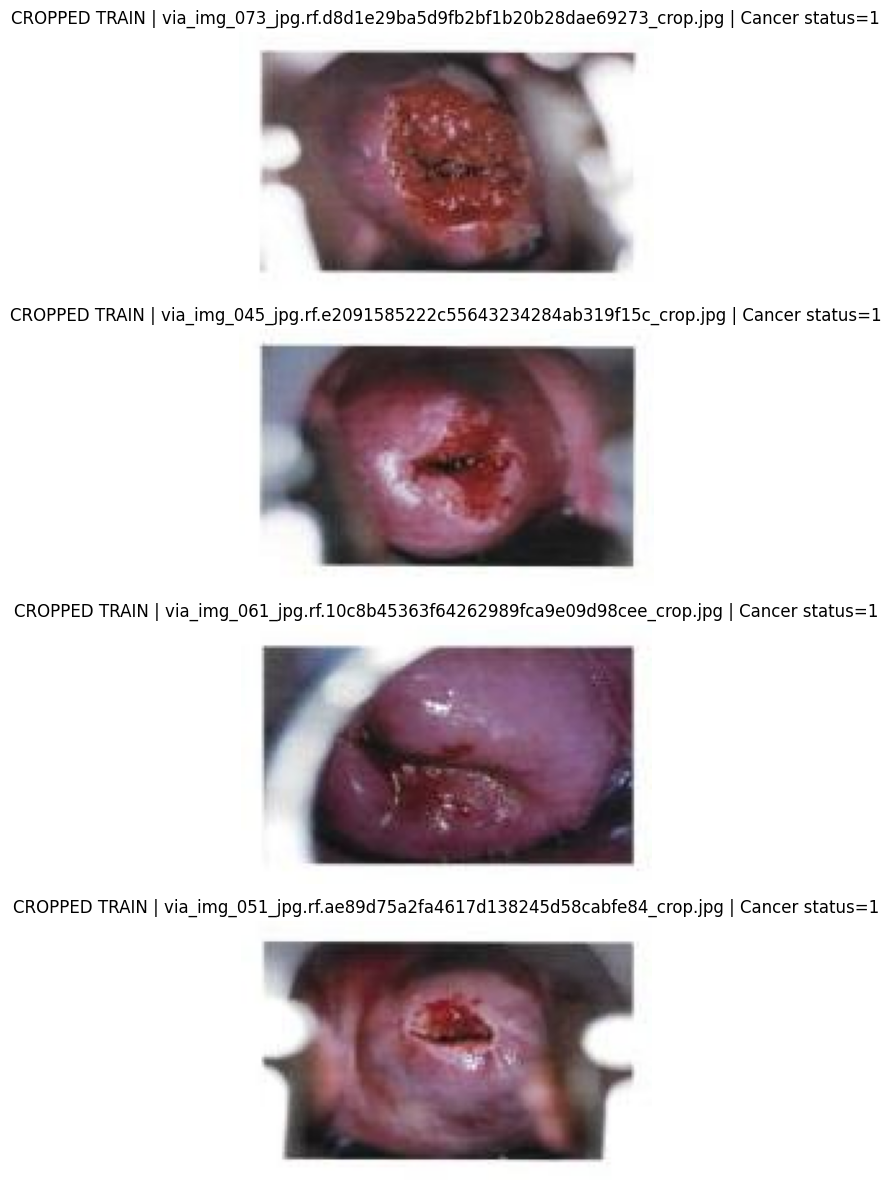

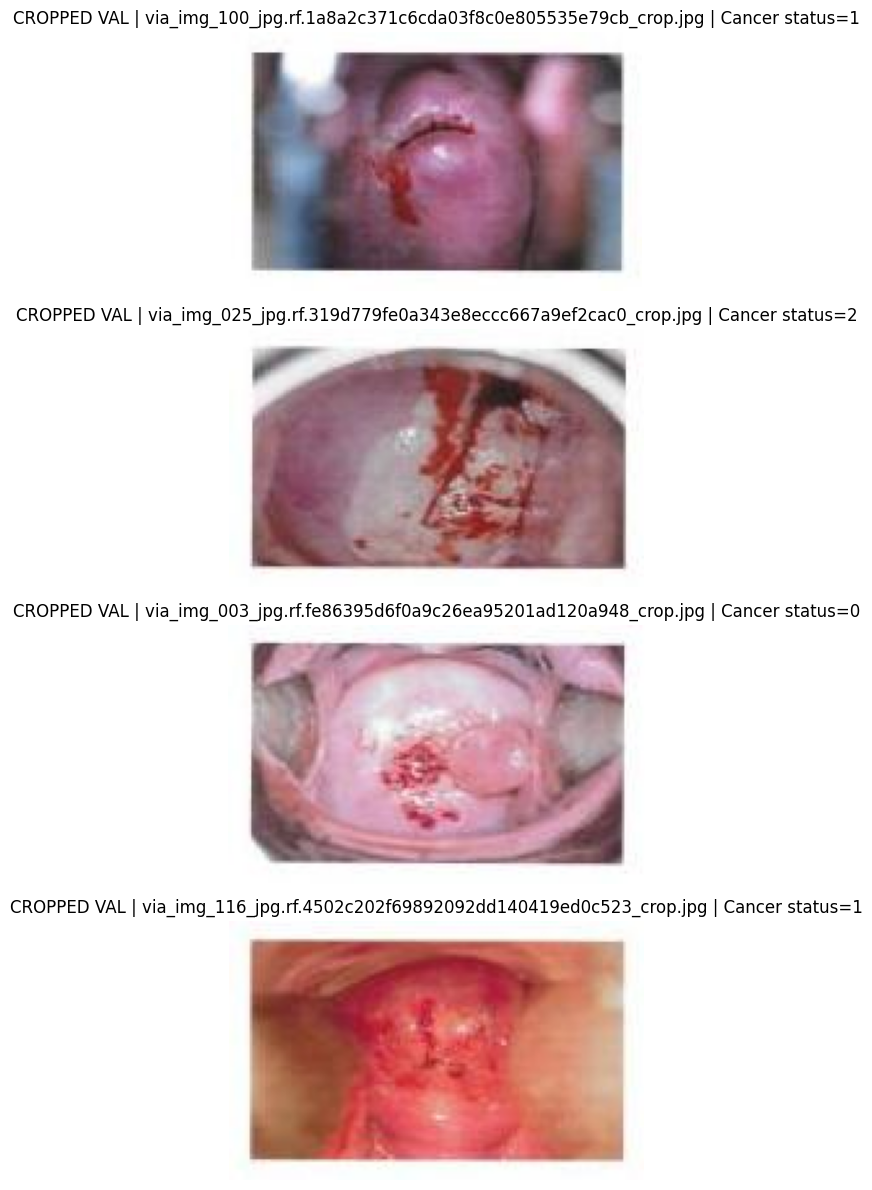

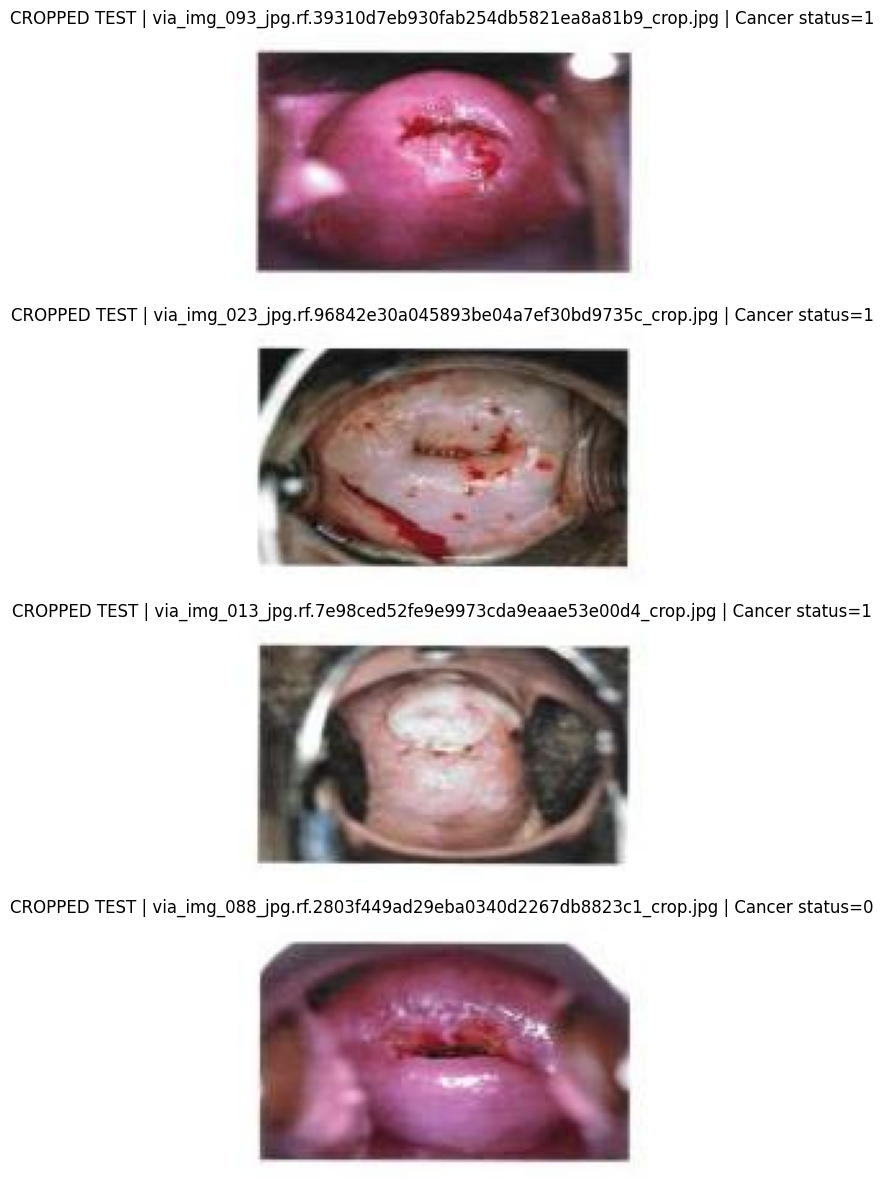

In [6]:
train_df_flash_raw = pd.read_csv(train_out_csv)
val_df_flash_raw   = pd.read_csv(val_out_csv)
test_df_flash_raw  = pd.read_csv(test_out_csv)

def show_samples(df, n=4, title=""):
    samples = df.sample(min(n, len(df))).reset_index(drop=True)
    plt.figure(figsize=(10, 3 * len(samples)))

    for i, row in samples.iterrows():
        img_path = Path(row["image_path"])
        img = Image.open(img_path).convert("RGB")

        plt.subplot(len(samples), 1, i + 1)
        plt.imshow(img)
        plt.axis("off")
        label_val = row["Cancer status"]
        plt.title(f"{title} | {img_path.name} | Cancer status={label_val}")

    plt.tight_layout()
    plt.show()

show_samples(train_df_flash_raw, n=4, title="CROPPED TRAIN")
show_samples(val_df_flash_raw,   n=4, title="CROPPED VAL")
show_samples(test_df_flash_raw,  n=4, title="CROPPED TEST")


## 6. Stratified Train/Val/Test Split – FLASHCARDS ONLY

Now I combine the old train/val/test into a single dataframe and do a fresh **stratified** split:

- Train: 70%
- Val: 15%
- Test: 15%

Stratification is based on `Cancer status` (0, 1, 2) to keep class proportions balanced.


In [30]:
# we perform stratified split
from sklearn.model_selection import train_test_split

# 70% train, 15% val, 15% test (stratified on Cancer status)
train_df, temp_df = train_test_split(
    full_df,
    test_size=0.3,
    stratify=full_df[LABEL_COL],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df[LABEL_COL],
    random_state=42
)

print("NEW TRAIN counts:\n", train_df[LABEL_COL].value_counts(), "\n")
print("NEW VAL counts:\n",   val_df[LABEL_COL].value_counts(), "\n")
print("NEW TEST counts:\n",  test_df[LABEL_COL].value_counts(), "\n")


NEW TRAIN counts:
 Cancer status
0    94
1    89
2     9
Name: count, dtype: int64 

NEW VAL counts:
 Cancer status
0    20
1    19
2     2
Name: count, dtype: int64 

NEW TEST counts:
 Cancer status
0    21
1    19
2     2
Name: count, dtype: int64 



## 7. Class Weights and DataLoaders (FLASHCARDS ONLY)

The dataset is imbalanced (very few Cancer cases).  
I compute **inverse-frequency class weights** and use them in cross-entropy loss.

I also define:

- Image transforms (augmentation for train, only resize + normalize for val/test)
- A `CervixDatasetPath` class that reads images from `image_path`
- A helper to create loaders from any train/val/test dataframes


In [31]:
import torch
import numpy as np

class_counts = train_df[LABEL_COL].value_counts().sort_index()
print("Class counts (train):", class_counts.to_dict())

# Inverse frequency weights
class_weights = 1.0 / class_counts.values.astype(float)
class_weights = class_weights / class_weights.sum()  # normalize
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights tensor:", class_weights_tensor)

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMAGE_PATH_COL = "image_path"   # very important
LABEL_COL      = "Cancer status"
IMG_SIZE       = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class CervixDatasetPath(Dataset):
    def __init__(self, df, path_col: str, label_col: str, transform=None):
        self.df = df.reset_index(drop=True)
        self.path_col = path_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = Path(row[self.path_col])
        label = int(row[self.label_col])

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, label
BATCH_SIZE = 16
NUM_WORKERS = 2

train_dataset = CervixDatasetPath(train_df, IMAGE_PATH_COL, LABEL_COL, transform=train_transform)
val_dataset   = CervixDatasetPath(val_df,   IMAGE_PATH_COL, LABEL_COL, transform=val_test_transform)
test_dataset  = CervixDatasetPath(test_df,  IMAGE_PATH_COL, LABEL_COL, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

len(train_loader), len(val_loader), len(test_loader)


Class counts (train): {0: 94, 1: 89, 2: 9}
Class weights tensor: tensor([0.0800, 0.0845, 0.8355])


(12, 3, 3)

## 8. Model Definition – SSL ResNet-50 Backbone + EfficientNet-Style Head

The classifier is:

- Backbone: **ResNet-50** loaded from `ssl_backbone_resnet50_epoch48.pth`
  (SimCLR-pretrained on unlabeled cervix images).
- Head: a small EfficientNet-style MLP:
  - 2048 → 512 → 128 → 3 (with BatchNorm and Dropout).

I freeze the backbone for Stage 1 (head-only training), then unfreeze for full fine-tuning.


In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

# ---- Efficient-style classifier head (instead of single Linear) ----
class EfficientHead(nn.Module):
    def __init__(self, in_features: int, num_classes: int):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(p=0.3)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        return x


def build_resnet50_with_eff_head(backbone_path,
                                 num_classes: int = 3,
                                 freeze_backbone: bool = True,
                                 device: str = "cuda"):
    """
    ResNet-50 backbone (Kaggle/SSL-pretrained) + Efficient-style classifier head.
    """
    model = models.resnet50(weights=None)

    # Load pretrained backbone weights
    ckpt = torch.load(backbone_path, map_location="cpu")
    if isinstance(ckpt, dict):
        cleaned = {k.replace("module.", ""): v for k, v in ckpt.items()}
    else:
        cleaned = ckpt

    missing, unexpected = model.load_state_dict(cleaned, strict=False)
    print("Loaded ResNet-50 Kaggle backbone.")
    print("Missing keys:", len(missing), "| Unexpected keys:", len(unexpected))

    # Replace FC with our Efficient-style head
    in_features = model.fc.in_features
    model.fc = EfficientHead(in_features, num_classes)

    if freeze_backbone:
        for name, p in model.named_parameters():
            p.requires_grad = False
        for p in model.fc.parameters():
            p.requires_grad = True

    return model.to(device)


## 9. Training Helper with Early Stopping

This function:

- Performs training and validation for multiple epochs.
- Tracks train/val loss and accuracy.
- Uses **early stopping** based on validation loss.
- Optionally evaluates on a test loader and returns:
  - Accuracy
  - Confusion matrix
  - Classification report.


In [41]:
# Model helpers
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

def train_model_best(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=20,
    patience=3,
    eval_loader=None,      # e.g. test_loader or val_loader
    label_names=None       # e.g. ["Normal", "Pre-cancerous", "Cancer"]
):
    """
    Train model with early stopping (based on val_loss).
    After training, optionally evaluate on eval_loader and return
    confusion matrix + classification report.
    """

    best_loss = float("inf")
    best_state = None
    best_epoch = -1
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    for epoch in range(1, epochs + 1):
        # ---- Train ----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validation ----
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
        )

        # track best epoch by val_loss
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = model.state_dict()
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping!")
            break

    print(f"\nBest epoch: {best_epoch} (val_loss = {best_loss:.4f})\n")

    # Load best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    metrics = None

    # ---- Optional evaluation (e.g. on test set) ----
    if eval_loader is not None:
        model.eval()
        all_labels = []
        all_preds = []

        with torch.no_grad():
            for imgs, labels in eval_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = torch.max(outputs, 1)

                all_labels.extend(labels.cpu().numpy().tolist())
                all_preds.extend(preds.cpu().numpy().tolist())

        all_labels = np.array(all_labels)
        all_preds = np.array(all_preds)

        acc = accuracy_score(all_labels, all_preds)
        cm = confusion_matrix(all_labels, all_preds)
        report = classification_report(
            all_labels,
            all_preds,
            target_names=label_names if label_names is not None else None,
            digits=4
        )

        print("=== Evaluation on eval_loader ===")
        print(f"Accuracy: {acc:.4f}\n")
        print("Classification report:")
        print(report)
        print("Confusion matrix:")
        print(cm)

        metrics = {
            "accuracy": acc,
            "confusion_matrix": cm,
            "classification_report": report,
        }

    # returns model with best weights, training history, and eval metrics if computed
    return model, history, best_state, best_epoch, metrics


## 10. Experiment 1 – FLASHCARDS ONLY

Here I train the ResNet-50 SSL backbone + Efficient head **only on cropped Jhpiego flashcards**.

Two-stage strategy:

- **Stage 1** (15 epochs): train only the head, backbone frozen.
- **Stage 2** (up to 25 epochs): unfreeze entire model and fine-tune.

I use:

- `AdamW` optimizer  
- Class-weighted cross-entropy (`class_weights_tensor_flash`)  
- Early stopping in both stages.


In [42]:
# ============================================================
# EfficientNet-style head + ResNet-50 backbone
# Flashcards-only data, stratified split, class-weighted loss
# Stage 1: Train head (backbone frozen)
# Stage 2: Fine-tune full model
# ============================================================

import torch.optim as optim
import torch.nn as nn

torch.manual_seed(42)

# NOTE: we assume you already defined:
#   - BACKBONE_PATH            (SSL/Kaggle backbone .pth)
#   - train_loader, val_loader, test_loader (flashcards-only)
#   - class_weights_tensor     (computed from flashcards train split)
label_names = ["Normal", "Pre-cancerous", "Cancer"]

# 🔹 Stage 1: Train only Efficient head (backbone frozen)
model_effhead = build_resnet50_with_eff_head(
    backbone_path=SSL_BACKBONE_PATH,    # your SSL-pretrained ResNet-50 .pth
    num_classes=3,
    freeze_backbone=True,
    device=device
)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model_effhead.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

print("\n=== Stage 1: Train Efficient head (ResNet backbone frozen) on FLASHCARDS ONLY ===")
model_effhead, hist_s1, best_state_s1, best_epoch_s1, metrics_s1 = train_model_best(
    model_effhead,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=15,
    patience=3,
    eval_loader=val_loader,             # optional: see head-only performance on val
    label_names=label_names
)

# 🔹 Stage 2: Unfreeze full backbone and fine-tune end-to-end
for p in model_effhead.parameters():
    p.requires_grad = True

optimizer = optim.AdamW(
    model_effhead.parameters(),
    lr=5e-5,               # smaller LR for fine-tuning
    weight_decay=1e-4
)

print("\n=== Stage 2: Fine-tune full ResNet-50 + Efficient head on FLASHCARDS ONLY ===")
model_effhead, hist_s2, best_state_s2, best_epoch_s2, metrics_s2 = train_model_best(
    model_effhead,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=25,
    patience=5,
    eval_loader=test_loader,            # FINAL evaluation on flashcards TEST set
    label_names=label_names
)

print("\nFinal TEST accuracy (Efficient head + ResNet backbone, FLASHCARDS ONLY): "
      f"{metrics_s2['accuracy']:.4f}")

# Confusion matrix and classification_report are already printed inside train_model_best,
# but you can also access them programmatically if needed:
cm_eff = metrics_s2["confusion_matrix"]
report_eff = metrics_s2["classification_report"]
print(report_eff)


Loaded ResNet-50 Kaggle backbone.
Missing keys: 2 | Unexpected keys: 0

=== Stage 1: Train Efficient head (ResNet backbone frozen) on FLASHCARDS ONLY ===
Epoch 01 | Train Loss: 1.1818, Acc: 0.2604 | Val Loss: 1.0814, Acc: 0.2439
Epoch 02 | Train Loss: 1.0089, Acc: 0.3542 | Val Loss: 1.0145, Acc: 0.3415
Epoch 03 | Train Loss: 0.9237, Acc: 0.4115 | Val Loss: 0.9380, Acc: 0.4634
Epoch 04 | Train Loss: 0.8744, Acc: 0.4531 | Val Loss: 0.8602, Acc: 0.6829
Epoch 05 | Train Loss: 0.8204, Acc: 0.5104 | Val Loss: 0.8771, Acc: 0.6585
Epoch 06 | Train Loss: 0.8379, Acc: 0.5260 | Val Loss: 0.8667, Acc: 0.6829
Epoch 07 | Train Loss: 0.7771, Acc: 0.5677 | Val Loss: 0.8669, Acc: 0.6585
Early stopping!

Best epoch: 4 (val_loss = 0.8602)

=== Evaluation on eval_loader ===
Accuracy: 0.6585

Classification report:
               precision    recall  f1-score   support

       Normal     0.6842    0.6500    0.6667        20
Pre-cancerous     0.8000    0.6316    0.7059        19
       Cancer     0.2857    

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | Train Loss: 0.7366, Acc: 0.5938 | Val Loss: 0.8096, Acc: 0.6098
Epoch 02 | Train Loss: 0.7044, Acc: 0.6354 | Val Loss: 0.8705, Acc: 0.6098
Epoch 03 | Train Loss: 0.6592, Acc: 0.6615 | Val Loss: 0.8133, Acc: 0.5854
Epoch 04 | Train Loss: 0.6130, Acc: 0.7344 | Val Loss: 0.7266, Acc: 0.7073
Epoch 05 | Train Loss: 0.6065, Acc: 0.7500 | Val Loss: 0.7110, Acc: 0.6829
Epoch 06 | Train Loss: 0.6004, Acc: 0.7812 | Val Loss: 0.6881, Acc: 0.6585
Epoch 07 | Train Loss: 0.5386, Acc: 0.8125 | Val Loss: 0.6677, Acc: 0.7073
Epoch 08 | Train Loss: 0.5057, Acc: 0.8333 | Val Loss: 0.7079, Acc: 0.6341
Epoch 09 | Train Loss: 0.4968, Acc: 0.8281 | Val Loss: 0.6348, Acc: 0.7317
Epoch 10 | Train Loss: 0.4196, Acc: 0.8750 | Val Loss: 0.5788, Acc: 0.7805
Epoch 11 | Train Loss: 0.4145, Acc: 0.8906 | Val Loss: 0.5928, Acc: 0.8049
Epoch 12 | Train Loss: 0.4447, Acc: 0.8438 | Val Loss: 0.6152, Acc: 0.6585
Epoch 13 | Train Loss: 0.3496, Acc: 0.8958 | Val Loss: 0.6275, Acc: 0.7561
Epoch 14 | Train Loss: 0.

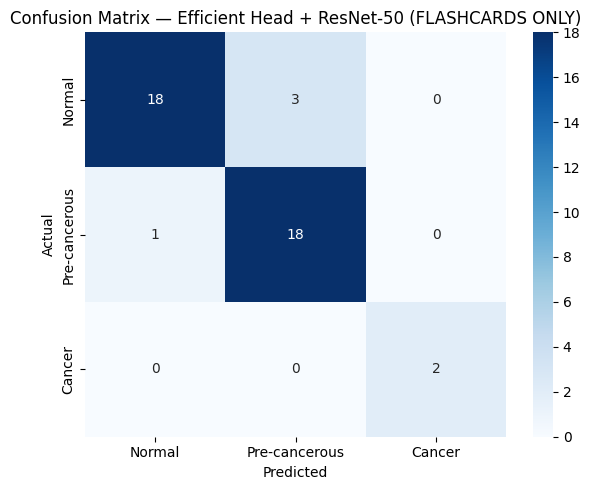

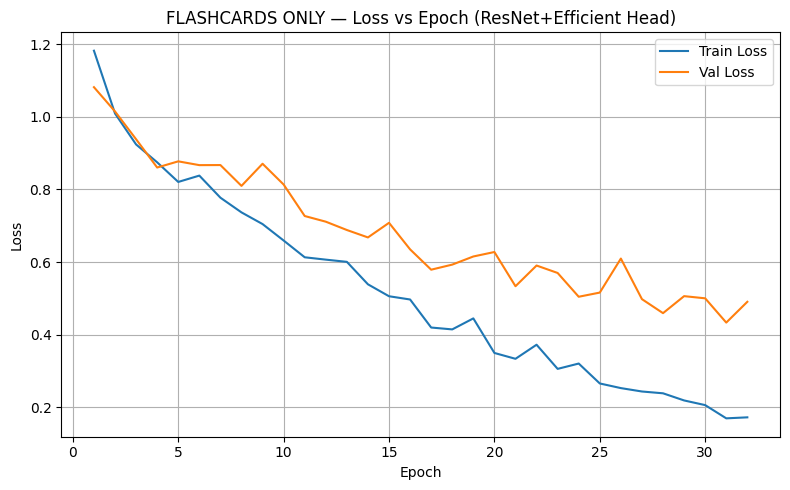

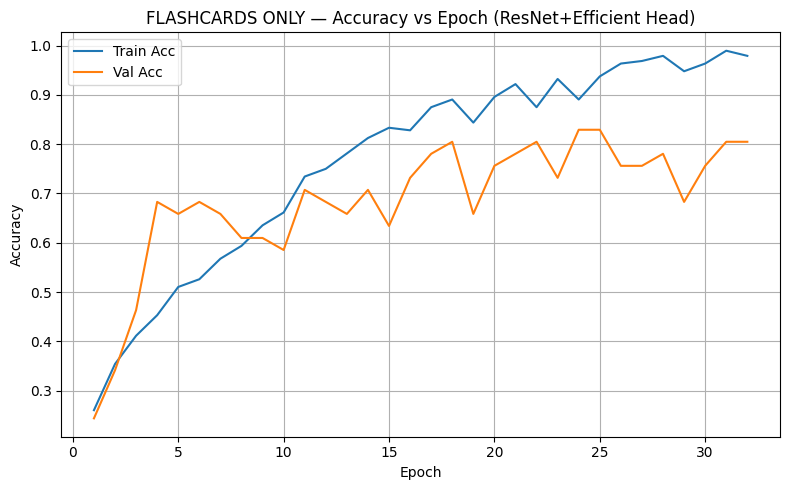

Saved BEST model to: /content/drive/MyDrive/classification_expts_flashcards/resnet_backbone_efficient_head_best.pth
Saved LAST model to: /content/drive/MyDrive/classification_expts_flashcards/resnet_backbone_efficient_head_last.pth


In [43]:
# ============================================================
# Visualise confusion matrix, curves & save model weights
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch

RESULTS_DIR = Path("/content/drive/MyDrive/classification_expts_flashcards")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ---- Confusion Matrix ----
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_eff,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title("Confusion Matrix — Efficient Head + ResNet-50 (FLASHCARDS ONLY)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "flashcards_confusion_matrix.png", dpi=200)
plt.show()

# ---- Loss & Accuracy Curves (Stage 1 + Stage 2 combined) ----
train_loss_all = hist_s1["train_loss"] + hist_s2["train_loss"]
val_loss_all   = hist_s1["val_loss"]   + hist_s2["val_loss"]
train_acc_all  = hist_s1["train_acc"]  + hist_s2["train_acc"]
val_acc_all    = hist_s1["val_acc"]    + hist_s2["val_acc"]

epochs_all = range(1, len(train_loss_all) + 1)

# Loss curve
plt.figure(figsize=(8,5))
plt.plot(epochs_all, train_loss_all, label="Train Loss")
plt.plot(epochs_all, val_loss_all,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("FLASHCARDS ONLY — Loss vs Epoch (ResNet+Efficient Head)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "flashcards_loss_curve.png", dpi=200)
plt.show()

# Accuracy curve
plt.figure(figsize=(8,5))
plt.plot(epochs_all, train_acc_all, label="Train Acc")
plt.plot(epochs_all, val_acc_all,   label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FLASHCARDS ONLY — Accuracy vs Epoch (ResNet+Efficient Head)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "flashcards_accuracy_curve.png", dpi=200)
plt.show()

# ---- Save best & last model weights ----
best_path = RESULTS_DIR / "resnet_backbone_efficient_head_best.pth"
last_path = RESULTS_DIR / "resnet_backbone_efficient_head_last.pth"

torch.save(best_state_s2, best_path)              # best epoch from Stage 2
torch.save(model_effhead.state_dict(), last_path) # last weights as trained

print("Saved BEST model to:", best_path)
print("Saved LAST model to:", last_path)


## 11. Experiment 2 – Merged Jhpiego + VIA_IARC Dataset

To increase sample size and test cross-dataset generalization, I merge:

- Cropped Jhpiego flashcards
- VIA_IARC dataset

Steps:

1. Convert VIA_IARC COCO annotations to `VIA_IARC_train_tags.csv`.
2. Add `image_path` for both Jhpiego and VIA_IARC images.
3. Concatenate into one dataframe and do a stratified train/val/test split.
4. Compute new class weights for the combined train split.
5. Train the same SSL ResNet-50 + Efficient head model on the combined data.


In [44]:
# Create VIA_IARC_train_tags.csv (if not already created)
# ============================================================
# STEP 1 — Build VIA_IARC_train_tags.csv from COCO JSON
# ============================================================
import json
import csv
from pathlib import Path
from collections import Counter

IARC_ROOT = Path("/content/drive/MyDrive/VIA_IARC.v1i.coco")
json_path = IARC_ROOT / "train" / "_annotations.coco.json"

cancer_map = {
    "Normal": 0,
    "Pre-cancerous": 1,
    "Cancerous": 2,
}

candidacy_map = {
    "Bad-candidate": 0,
    "Good-candidate": 1,
}

rows = []
with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

for img in data.get("images", []):
    file_name = img["file_name"]
    tags = img.get("extra", {}).get("user_tags", [])

    cancer_status = None
    candidacy = None

    for tag in tags:
        if tag in cancer_map:
            cancer_status = cancer_map[tag]
        if tag in candidacy_map:
            candidacy = candidacy_map[tag]

    if cancer_status is None:
        continue

    if candidacy is None:
        candidacy = ""

    rows.append([file_name, cancer_status, candidacy])

csv_path = IARC_ROOT / "VIA_IARC_train_tags.csv"
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["image", "Cancer status", "Candidacy"])
    writer.writerows(rows)

print("CSV created:", csv_path)
print("Number of rows:", len(rows))
print("Cancer status counts:", Counter(r[1] for r in rows))


CSV created: /content/drive/MyDrive/VIA_IARC.v1i.coco/VIA_IARC_train_tags.csv
Number of rows: 182
Cancer status counts: Counter({1: 89, 0: 60, 2: 33})


In [45]:
# Build Combined DataFrames & Split
# STEP 2 — Merge CROPPED_FLASHCARDS + VIA_IARC, stratified split
# ============================================================
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path

JH_ROOT   = Path("/content/drive/MyDrive/FLASHCARDS_DATA/CROPPED_FLASHCARDS")
IARC_ROOT = Path("/content/drive/MyDrive/VIA_IARC.v1i.coco")

LABEL_COL = "Cancer status"

# ----- Jhpiego: use the cropped CSVs with correct image_path -----
df_jh_train = pd.read_csv(JH_ROOT / "train_tags.csv")
df_jh_val   = pd.read_csv(JH_ROOT / "val_tags.csv")
df_jh_test  = pd.read_csv(JH_ROOT / "test_tags.csv")

df_jh = pd.concat([df_jh_train, df_jh_val, df_jh_test], ignore_index=True)

# Sanity check: make sure image_path exists
assert "image_path" in df_jh.columns, "Jhpiego CSVs must have image_path from cropping step"

# ----- VIA_IARC: CSV we just created -----
df_iarc = pd.read_csv(IARC_ROOT / "VIA_IARC_train_tags.csv")

df_iarc["image_path"] = df_iarc["image"].apply(
    lambda x: str(IARC_ROOT / "train" / x)
)

# ----- Combine both datasets -----
df_all = pd.concat([df_jh, df_iarc], ignore_index=True)
df_all[LABEL_COL] = df_all[LABEL_COL].astype(int)

print("Merged dataset shape:", df_all.shape)
print("Merged class counts:\n", df_all[LABEL_COL].value_counts(), "\n")

# ----- Stratified split: 70% train, 15% val, 15% test -----
train_df_comb, temp_df_comb = train_test_split(
    df_all,
    test_size=0.30,
    stratify=df_all[LABEL_COL],
    random_state=42,
)

val_df_comb, test_df_comb = train_test_split(
    temp_df_comb,
    test_size=0.50,
    stratify=temp_df_comb[LABEL_COL],
    random_state=42,
)

print("COMBINED TRAIN counts:\n", train_df_comb[LABEL_COL].value_counts(), "\n")
print("COMBINED VAL counts:\n",   val_df_comb[LABEL_COL].value_counts(), "\n")
print("COMBINED TEST counts:\n",  test_df_comb[LABEL_COL].value_counts(), "\n")

# ----- Save split (optional but nice) -----
SPLIT_ROOT = Path("/content/drive/MyDrive/FINAL_COMBINED_SPLIT_FIXED")
SPLIT_ROOT.mkdir(exist_ok=True)

train_df_comb.to_csv(SPLIT_ROOT / "train_combined.csv", index=False)
val_df_comb.to_csv(SPLIT_ROOT / "val_combined.csv", index=False)
test_df_comb.to_csv(SPLIT_ROOT / "test_combined.csv", index=False)

print("Saved combined splits to:", SPLIT_ROOT)

Merged dataset shape: (296, 4)
Merged class counts:
 Cancer status
1    142
0    116
2     38
Name: count, dtype: int64 

COMBINED TRAIN counts:
 Cancer status
1    99
0    81
2    27
Name: count, dtype: int64 

COMBINED VAL counts:
 Cancer status
1    21
0    17
2     6
Name: count, dtype: int64 

COMBINED TEST counts:
 Cancer status
1    22
0    18
2     5
Name: count, dtype: int64 

Saved combined splits to: /content/drive/MyDrive/FINAL_COMBINED_SPLIT_FIXED


In [46]:
# Combined Class Weights & Loaders
# STEP 3 — Class weights + DataLoaders (COMBINED)
# ============================================================
import torch
import numpy as np
from torch.utils.data import DataLoader

from pathlib import Path
import pandas as pd

SPLIT_ROOT = Path("/content/drive/MyDrive/FINAL_COMBINED_SPLIT_FIXED")

train_df_combined = pd.read_csv(SPLIT_ROOT / "train_combined.csv")
val_df_combined   = pd.read_csv(SPLIT_ROOT / "val_combined.csv")
test_df_combined  = pd.read_csv(SPLIT_ROOT / "test_combined.csv")

LABEL_COL      = "Cancer status"
IMAGE_PATH_COL = "image_path"

# Ensure labels are ints
for df in [train_df_combined, val_df_combined, test_df_combined]:
    df[LABEL_COL] = df[LABEL_COL].astype(int)

print("Train counts:\n", train_df_combined[LABEL_COL].value_counts(), "\n")
print("Val counts:\n",   val_df_combined[LABEL_COL].value_counts(), "\n")
print("Test counts:\n",  test_df_combined[LABEL_COL].value_counts(), "\n")

# ---- Class weights for combined TRAIN ----
class_counts_combined = train_df_combined[LABEL_COL].value_counts().sort_index()
print("Combined TRAIN class counts:", class_counts_combined.to_dict())

class_weights_combined = 1.0 / class_counts_combined.values.astype(float)
class_weights_combined = class_weights_combined / class_weights_combined.sum()

class_weights_tensor_combined = torch.tensor(
    class_weights_combined, dtype=torch.float32
).to(device)

print("Combined class weights tensor:", class_weights_tensor_combined)

# ---- Datasets & loaders ----
BATCH_SIZE   = 16
NUM_WORKERS  = 2

train_dataset_combined = CervixDatasetPath(
    train_df_combined,
    IMAGE_PATH_COL,
    LABEL_COL,
    transform=train_transform,
)

val_dataset_combined = CervixDatasetPath(
    val_df_combined,
    IMAGE_PATH_COL,
    LABEL_COL,
    transform=val_test_transform,
)

test_dataset_combined = CervixDatasetPath(
    test_df_combined,
    IMAGE_PATH_COL,
    LABEL_COL,
    transform=val_test_transform,
)

train_loader_combined = DataLoader(
    train_dataset_combined,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader_combined = DataLoader(
    val_dataset_combined,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader_combined = DataLoader(
    test_dataset_combined,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

len(train_loader_combined), len(val_loader_combined), len(test_loader_combined)

Train counts:
 Cancer status
1    99
0    81
2    27
Name: count, dtype: int64 

Val counts:
 Cancer status
1    21
0    17
2     6
Name: count, dtype: int64 

Test counts:
 Cancer status
1    22
0    18
2     5
Name: count, dtype: int64 

Combined TRAIN class counts: {0: 81, 1: 99, 2: 27}
Combined class weights tensor: tensor([0.2075, 0.1698, 0.6226])


(13, 3, 3)

In [48]:
# Train on Combined Dataset
# STEP 4 — Experiment 2: Efficient head + ResNet-50 (COMBINED)
# ============================================================
import torch.optim as optim
import torch.nn as nn

torch.manual_seed(42)

label_names = ["Normal", "Pre-cancerous", "Cancer"]

# 🔹 Stage 1: Train only Efficient head (backbone frozen)
model_effhead_combined = build_resnet50_with_eff_head(
    backbone_path=SSL_BACKBONE_PATH,   # same SSL/Kaggle backbone you used in Exp 1
    num_classes=3,
    freeze_backbone=True,
    device=device,
)

criterion_combined = nn.CrossEntropyLoss(weight=class_weights_tensor_combined)

optimizer_combined = optim.AdamW(
    filter(lambda p: p.requires_grad, model_effhead_combined.parameters()),
    lr=1e-4,
    weight_decay=1e-4,
)

print("\n=== COMBINED – Stage 1: Efficient head (ResNet frozen) ===")
model_effhead_combined, history_combined_s1, best_state_combined_s1, best_epoch_combined_s1, metrics_combined_s1 = train_model_best(
    model_effhead_combined,
    train_loader_combined,
    val_loader_combined,
    optimizer_combined,
    criterion_combined,
    device,
    epochs=15,
    patience=3,
    eval_loader=val_loader_combined,   # head-only performance
    label_names=label_names,
)

# 🔹 Stage 2: Unfreeze backbone and fine-tune end-to-end
for p in model_effhead_combined.parameters():
    p.requires_grad = True

optimizer_combined = optim.AdamW(
    model_effhead_combined.parameters(),
    lr=5e-5,
    weight_decay=1e-4,
)

print("\n=== COMBINED – Stage 2: Full fine-tuning ===")
model_effhead_combined, history_combined_s2, best_state_combined_s2, best_epoch_combined_s2, metrics_combined_s2 = train_model_best(
    model_effhead_combined,
    train_loader_combined,
    val_loader_combined,
    optimizer_combined,
    criterion_combined,
    device,
    epochs=25,
    patience=5,
    eval_loader=test_loader_combined,  # FINAL evaluation
    label_names=label_names,
)

print("\nFinal COMBINED TEST accuracy (Efficient head + ResNet backbone): "
      f"{metrics_combined_s2['accuracy']:.4f}")

cm_eff_combined     = metrics_combined_s2["confusion_matrix"]
report_eff_combined = metrics_combined_s2["classification_report"]
print("\nClassification report (COMBINED):\n", report_eff_combined)
print("Confusion matrix (COMBINED):\n", cm_eff_combined)



Loaded ResNet-50 Kaggle backbone.
Missing keys: 2 | Unexpected keys: 0

=== COMBINED – Stage 1: Efficient head (ResNet frozen) ===


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | Train Loss: 1.1339, Acc: 0.3285 | Val Loss: 1.0388, Acc: 0.1818
Epoch 02 | Train Loss: 0.9283, Acc: 0.4783 | Val Loss: 0.9716, Acc: 0.3864
Epoch 03 | Train Loss: 0.9263, Acc: 0.5217 | Val Loss: 0.9792, Acc: 0.3409
Epoch 04 | Train Loss: 0.9103, Acc: 0.5072 | Val Loss: 0.9447, Acc: 0.3864
Epoch 05 | Train Loss: 0.8280, Acc: 0.5362 | Val Loss: 0.9367, Acc: 0.4318
Epoch 06 | Train Loss: 0.8126, Acc: 0.5459 | Val Loss: 0.9956, Acc: 0.3636
Epoch 07 | Train Loss: 0.7976, Acc: 0.5652 | Val Loss: 0.9985, Acc: 0.3864
Epoch 08 | Train Loss: 0.7669, Acc: 0.5845 | Val Loss: 0.9474, Acc: 0.4773
Early stopping!

Best epoch: 5 (val_loss = 0.9367)

=== Evaluation on eval_loader ===
Accuracy: 0.4773

Classification report:
               precision    recall  f1-score   support

       Normal     0.5417    0.7647    0.6341        17
Pre-cancerous     0.5714    0.1905    0.2857        21
       Cancer     0.3077    0.6667    0.4211         6

     accuracy                         0.4773       

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | Train Loss: 0.8136, Acc: 0.6087 | Val Loss: 0.9871, Acc: 0.4773
Epoch 02 | Train Loss: 0.7380, Acc: 0.5797 | Val Loss: 0.9855, Acc: 0.4773
Epoch 03 | Train Loss: 0.6917, Acc: 0.6184 | Val Loss: 1.0007, Acc: 0.3864
Epoch 04 | Train Loss: 0.6839, Acc: 0.6570 | Val Loss: 1.0375, Acc: 0.4091
Epoch 05 | Train Loss: 0.5574, Acc: 0.7150 | Val Loss: 1.0247, Acc: 0.4773
Epoch 06 | Train Loss: 0.6346, Acc: 0.6667 | Val Loss: 1.0493, Acc: 0.4545
Epoch 07 | Train Loss: 0.6050, Acc: 0.6908 | Val Loss: 1.0691, Acc: 0.4545
Early stopping!

Best epoch: 2 (val_loss = 0.9855)

=== Evaluation on eval_loader ===
Accuracy: 0.3778

Classification report:
               precision    recall  f1-score   support

       Normal     0.5000    0.5000    0.5000        18
Pre-cancerous     0.5000    0.3182    0.3889        22
       Cancer     0.0769    0.2000    0.1111         5

     accuracy                         0.3778        45
    macro avg     0.3590    0.3394    0.3333        45
 weighted avg   

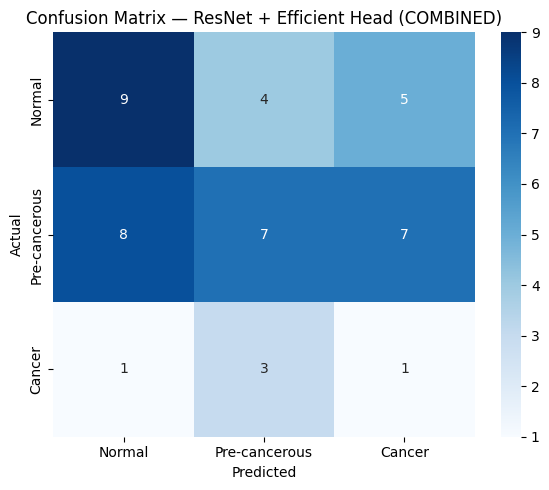

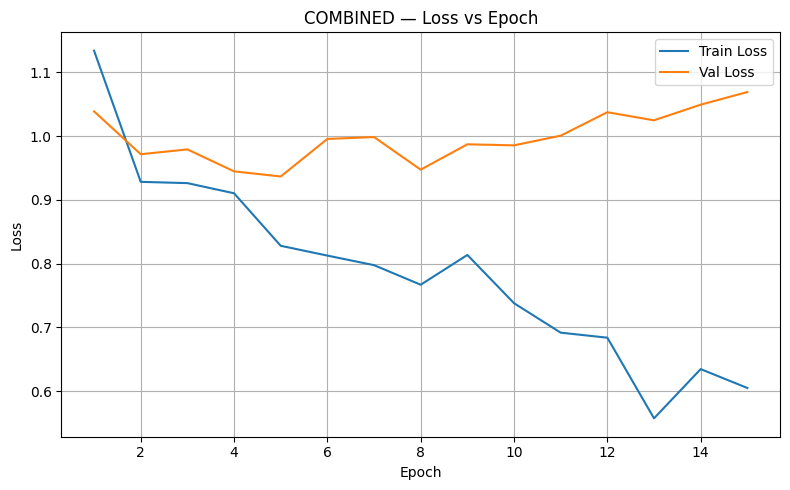

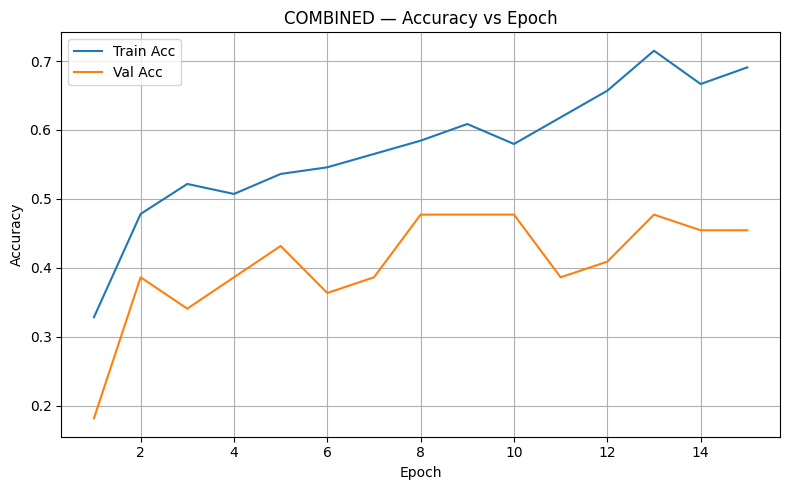

Saved COMBINED BEST model to: /content/drive/MyDrive/classification_expts/resnet_effhead_combined_best.pth
Saved COMBINED LAST model to: /content/drive/MyDrive/classification_expts/resnet_effhead_combined_last.pth
Files in RESULTS_DIR:


0

In [49]:
# Combined Confusion Matrix & Curves
# STEP 5 — Visualize CM + curves, save models (COMBINED)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

RESULTS_DIR = Path("/content/drive/MyDrive/classification_expts")
RESULTS_DIR.mkdir(exist_ok=True)

# ---- Confusion Matrix ----
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_eff_combined,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.title("Confusion Matrix — ResNet + Efficient Head (COMBINED)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "combined_confusion_matrix.png", dpi=200)
plt.show()

# ---- Loss & Accuracy curves (Stage 1 + Stage 2 combined) ----
train_loss_all_comb = history_combined_s1["train_loss"] + history_combined_s2["train_loss"]
val_loss_all_comb   = history_combined_s1["val_loss"]   + history_combined_s2["val_loss"]
train_acc_all_comb  = history_combined_s1["train_acc"]  + history_combined_s2["train_acc"]
val_acc_all_comb    = history_combined_s1["val_acc"]    + history_combined_s2["val_acc"]

epochs_all_comb = range(1, len(train_loss_all_comb) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_all_comb, train_loss_all_comb, label="Train Loss")
plt.plot(epochs_all_comb, val_loss_all_comb,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("COMBINED — Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "combined_loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_all_comb, train_acc_all_comb, label="Train Acc")
plt.plot(epochs_all_comb, val_acc_all_comb,   label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("COMBINED — Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "combined_accuracy_curve.png", dpi=200)
plt.show()

# ---- Save models ----
best_path_comb = RESULTS_DIR / "resnet_effhead_combined_best.pth"
last_path_comb = RESULTS_DIR / "resnet_effhead_combined_last.pth"

torch.save(best_state_combined_s2, best_path_comb)
torch.save(model_effhead_combined.state_dict(), last_path_comb)

print("Saved COMBINED BEST model to:", best_path_comb)
print("Saved COMBINED LAST model to:", last_path_comb)
print("Files in RESULTS_DIR:")
os.system(f'ls -lh "{RESULTS_DIR}"')

## 12. Gradio GUI for Testing the Classifier

Finally, I build a small GUI so that I can upload VIA images and see:

- Predicted label (Normal / Pre-Cancerous / Cancerous)
- Class probabilities

Here I load the **combined best model** (`resnet_effhead_combined_best.pth`).


In [17]:
# Build same architecture for inference
def build_resnet50_with_eff_head_infer(backbone_path, num_classes=3, device=device):
    model = models.resnet50(weights=None)

    ckpt = torch.load(backbone_path, map_location="cpu")
    if isinstance(ckpt, dict):
        cleaned = {k.replace("module.", ""): v for k, v in ckpt.items()}
    else:
        cleaned = ckpt

    missing, unexpected = model.load_state_dict(cleaned, strict=False)
    print("Loaded ResNet-50 SSL backbone for inference.")
    print("Missing keys:", len(missing), "| Unexpected keys:", len(unexpected))

    in_features = model.fc.in_features
    model.fc = EfficientHead(in_features, num_classes)
    model.to(device)
    model.eval()
    return model

# load combined best weights
infer_model = build_resnet50_with_eff_head(
    backbone_path=SSL_BACKBONE_PATH,
    num_classes=3,
    freeze_backbone=False,
    device=device
)
combined_best_path = RESULTS_DIR / "resnet_effhead_combined_best.pth"
state_dict_combined = torch.load(combined_best_path, map_location=device)
infer_model.load_state_dict(state_dict_combined)
infer_model.eval()

infer_transform = val_test_transform  # same as test

@torch.no_grad()
def predict_image_resnet(img: Image.Image):
    x = infer_transform(img).unsqueeze(0).to(device)
    logits = infer_model(x)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = int(probs.argmax())
    pred_label = label_names[pred_idx]
    prob_dict = {label_names[i]: float(probs[i]) for i in range(len(label_names))}
    return pred_label, prob_dict

def gradio_predict(img):
    pil_img = Image.fromarray(img.astype("uint8"))
    label, prob_dict = predict_image_resnet(pil_img)
    prob_text = "\n".join([f"{k}: {v:.3f}" for k, v in prob_dict.items()])
    return f"Prediction: {label}\n\nProbabilities:\n{prob_text}"

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="numpy", label="Upload VIA image"),
    outputs=gr.Textbox(label="Result"),
    title="Cervical VIA Classifier (SSL ResNet-50 + Efficient Head)",
    description="Trained on merged Jhpiego flashcards + VIA_IARC dataset"
)

demo.launch(share=False)


Loaded ResNet-50 Kaggle/SSL backbone.
Missing keys: 2 | Unexpected keys: 0
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>